In [1]:
import pandas as pd
import numpy as np
import seaborn as sns

In [2]:
df=pd.read_csv('insurance.csv',lineterminator='\n')

In [3]:
df.head()

,age,sex,bmi,children,smoker,region,charges\r
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
df.shape

(1338, 7)

In [5]:
df=df.drop('region',axis=1)

In [6]:
df.head()

,age,sex,bmi,children,smoker,charges\r
0,19,female,27.900,0,yes,16884.92400
1,18,male,33.770,1,no,1725.55230
2,28,male,33.000,3,no,4449.46200
3,33,male,22.705,0,no,21984.47061
4,32,male,28.880,0,no,3866.85520


In [7]:
df.columns=df.columns.str.replace('\r','')
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'charges'], dtype='object')

In [8]:
df.head()

,age,sex,bmi,children,smoker,charges
0,19,female,27.900,0,yes,16884.92400
1,18,male,33.770,1,no,1725.55230
2,28,male,33.000,3,no,4449.46200
3,33,male,22.705,0,no,21984.47061
4,32,male,28.880,0,no,3866.85520


In [9]:
# Label Encoding

from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()

df['sex_encode']=le.fit_transform(df['sex'])
df['smoker_type']=le.fit_transform(df['smoker'])

In [10]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'charges', 'sex_encode',
       'smoker_type'],
      dtype='object')

In [11]:
df.head()

,age,sex,bmi,children,smoker,charges,sex_encode,smoker_type
0,19,female,27.900,0,yes,16884.92400,0,1
1,18,male,33.770,1,no,1725.55230,1,0
2,28,male,33.000,3,no,4449.46200,1,0
3,33,male,22.705,0,no,21984.47061,1,0
4,32,male,28.880,0,no,3866.85520,1,0


<Axes: xlabel='bmi', ylabel='charges'>

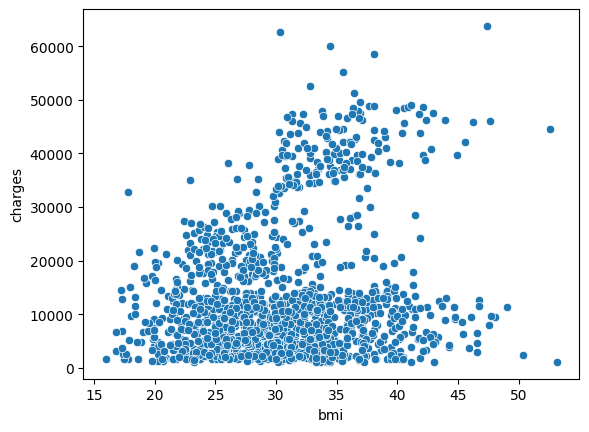

In [12]:
sns.scatterplot(x=df['bmi'],y=df['charges'])

<Axes: xlabel='bmi', ylabel='charges'>

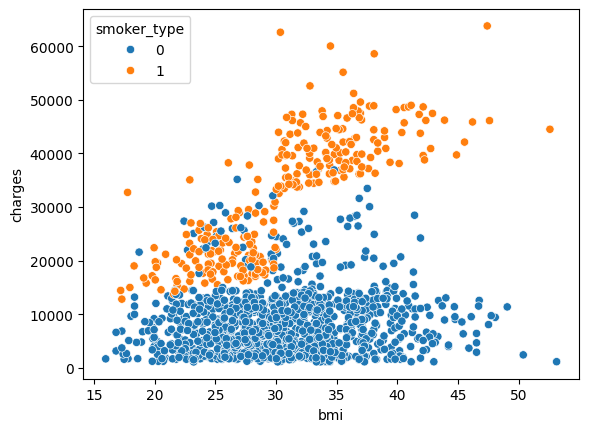

In [13]:
sns.scatterplot(x=df['bmi'],y=df['charges'],hue=df['smoker_type'])

In [14]:
df.head()

,age,sex,bmi,children,smoker,charges,sex_encode,smoker_type
0,19,female,27.900,0,yes,16884.92400,0,1
1,18,male,33.770,1,no,1725.55230,1,0
2,28,male,33.000,3,no,4449.46200,1,0
3,33,male,22.705,0,no,21984.47061,1,0
4,32,male,28.880,0,no,3866.85520,1,0


In [15]:
x=df[['age','bmi','children','sex_encode','smoker_type']]

In [16]:
y=df['charges']

In [17]:
y.head()

0    16884.92400
1     1725.55230
2     4449.46200
3    21984.47061
4     3866.85520
Name: charges, dtype: float64

In [18]:
# Train Test Split
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [19]:
x_train.head()

,age,bmi,children,sex_encode,smoker_type
560,46,19.95,2,0,0
1285,47,24.32,0,0,0
1142,52,24.86,0,0,0
969,39,34.32,5,0,0
486,54,21.47,3,0,0


In [20]:
y_train.head()

560      9193.83850
1285     8534.67180
1142    27117.99378
969      8596.82780
486     12475.35130
Name: charges, dtype: float64

In [21]:
x_test.head()

,age,bmi,children,sex_encode,smoker_type
764,45,25.175,2,0,0
887,36,30.020,0,0,0
890,64,26.885,0,0,1
1293,46,25.745,3,1,0
259,19,31.920,0,1,1


In [22]:
y_test.head()

764      9095.06825
887      5272.17580
890     29330.98315
1293     9301.89355
259     33750.29180
Name: charges, dtype: float64

In [1]:
# Trin the model

from sklearn.linear_model import LinearRegression
model=LinearRegression()

model.fit(x_train,y_train)

NameError: name 'x_train' is not defined

In [ ]:
# predict values

y_pred=model.predict(x_test)

In [ ]:
y_pred

In [26]:
y_test

764      9095.06825
887      5272.17580
890     29330.98315
1293     9301.89355
259     33750.29180
           ...     
109     47055.53210
575     12222.89830
535      6067.12675
543     63770.42801
846      9872.70100
Name: charges, Length: 268, dtype: float64

In [30]:
# Evaluation Metrics

from sklearn.metrics import r2_score
r2=r2_score(y_test, y_pred)
print("r-squared Value",r2)


n=x_test.shape[0]
p=x_test.shape[1]

adjusted_r2=1 - ((1-r2) * (n-1) / (n-p-1))
print('adjusteed_value',adjusted_r2)

r-squared Value 0.7811302113434095
adjusteed_value 0.7769533069797342


In [2]:
import seaborn as sns
print('All done')

All done
